# CHES2025 dataset analysis

In [1]:
# load the data
import numpy as np
from src.utils import load_ctf_2025
(X_profiling, X_attack), (Y_profiling, Y_attack), (P_profiling, P_attack), (K_profiling, K_attack) = load_ctf_2025("Dataset/CHES_2025/CHES_Challenge.h5", 0, 0, 500_000, 0, 100_000)

Information about the dataset: 
X_profiling total shape (500000, 7000)
Y_profiling total shape (500000,)
P_profiling total shape (500000,)
X_attack total shape (100000, 7000)
Y_attack total shape (100000,)
P_attack total shape (100000,)
correct key: 127



In [2]:
# define the function to plot traces
def plot_trace(trace, title='Trace', xlabel='Sample Index', ylabel='Value'):
    import matplotlib.pyplot as plt
    plt.plot(trace)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

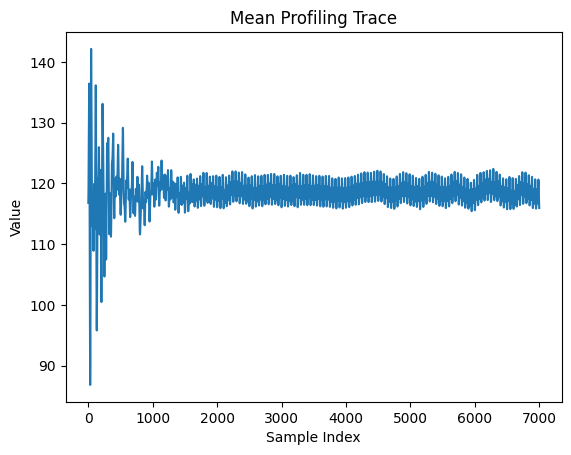

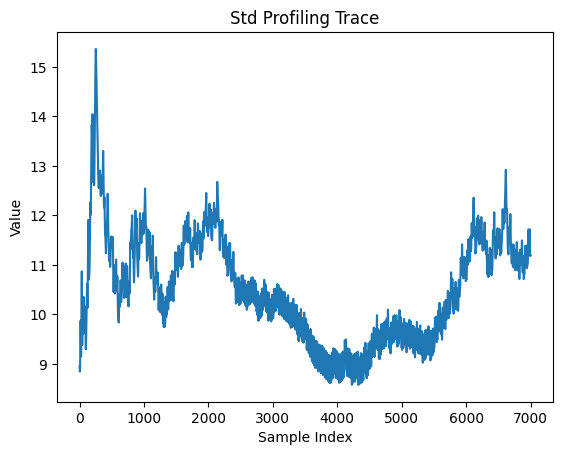

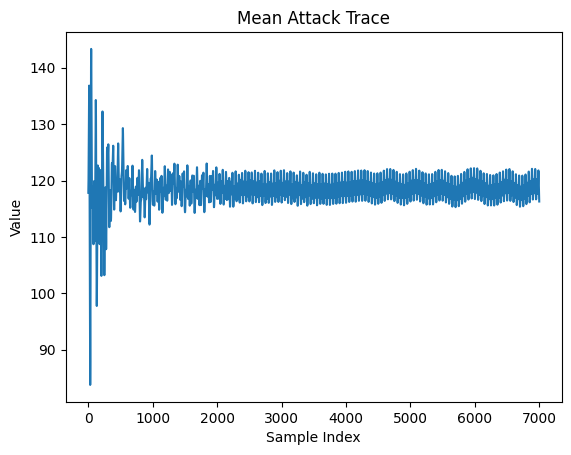

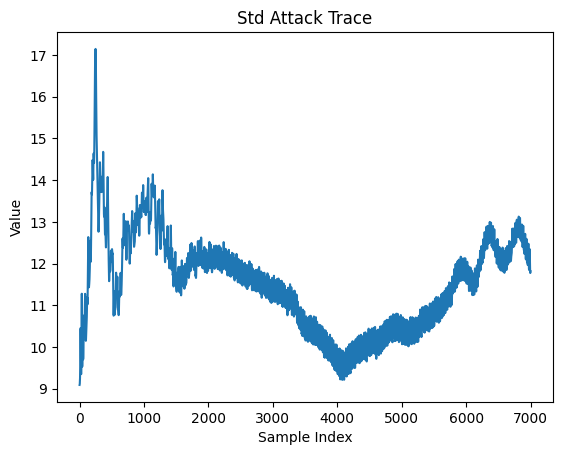

In [3]:
# calculate the mean and std for traces
import torch
X_profiling_tensor = torch.from_numpy(X_profiling).float().to('cuda')
X_attack_tensor = torch.from_numpy(X_attack).float().to('cuda')

mean_profiling = X_profiling_tensor.mean(dim=0, keepdim=False).cpu().numpy()
std_profiling = X_profiling_tensor.std(dim=0, keepdim=False, unbiased=False).cpu().numpy()

mean_attack = X_attack_tensor.mean(dim=0, keepdim=False).cpu().numpy()
std_attack = X_attack_tensor.std(dim=0, keepdim=False, unbiased=False).cpu().numpy()

# plot the four traces
plot_trace(mean_profiling, title='Mean Profiling Trace')
plot_trace(std_profiling, title='Std Profiling Trace')
plot_trace(mean_attack, title='Mean Attack Trace')
plot_trace(std_attack, title='Std Attack Trace')

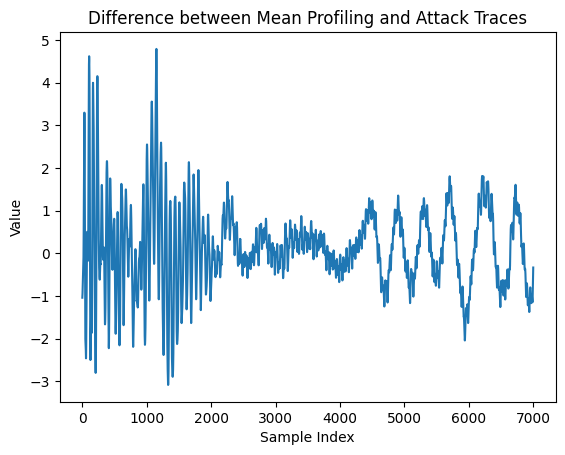

In [4]:
# show the difference between the mean of profiling and attack traces
plot_trace(mean_profiling - mean_attack, title='Difference between Mean Profiling and Attack Traces')

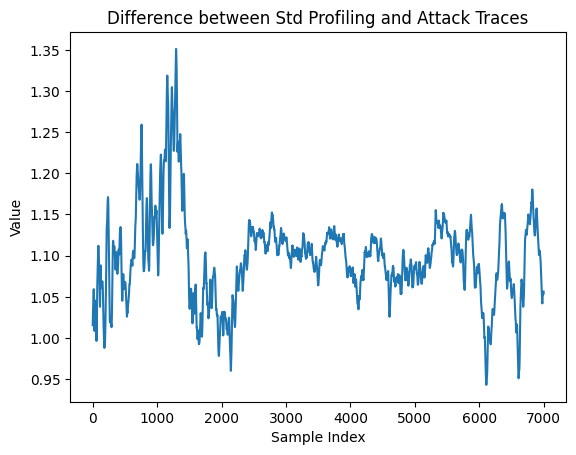

In [5]:
# show the difference between the std of profiling and attack traces
plot_trace(std_attack/std_profiling, title='Difference between Std Profiling and Attack Traces')

### Calculating the correct correction

In [5]:
# collect all traces with key 127 from profiling data
X_profiling_raw_key_127 = []
for i in range(len(X_profiling)):
    if K_profiling[i] == 127:
        X_profiling_raw_key_127.append(X_profiling[i])

X_profiling_raw_key_127 = np.array(X_profiling_raw_key_127)

mean_profiling_raw_key_127 = X_profiling_raw_key_127.mean(axis=0)
std_profiling_raw_key_127 = X_profiling_raw_key_127.std(axis=0, ddof=0)

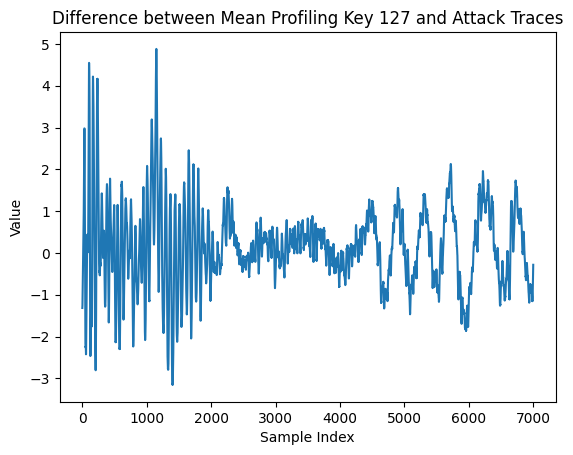

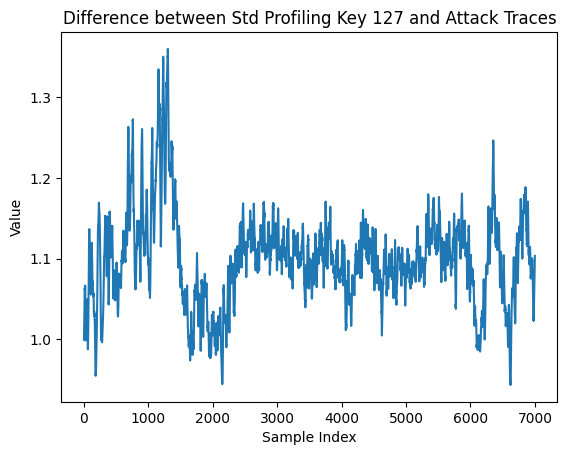

In [6]:
# compare with attack traces
plot_trace(mean_profiling_raw_key_127 - mean_attack, title='Difference between Mean Profiling Key 127 and Attack Traces')
plot_trace(std_attack/std_profiling_raw_key_127, title='Difference between Std Profiling Key 127 and Attack Traces')

### Apply the correction

In [7]:
# correct the X_attack traces to match the profiling traces
# mean(X') = mean_profiling_raw_key_127
# std(X')  = std_profiling_raw_key_127
X_attack_corrected = (X_attack - mean_attack) * (std_profiling_raw_key_127 / std_attack) + mean_profiling_raw_key_127
X_attack_corrected_standard = (X_attack_corrected - mean_profiling) / std_profiling
X_attack_corrected_standard

array([[-0.57025141, -0.52447703, -0.72741597, ..., -0.53965074,
        -0.59824971, -0.58567708],
       [-0.12314645, -0.07805029, -0.27884943, ...,  0.19553707,
         0.46037648,  0.38652646],
       [ 0.10040603,  0.14516308,  0.05757548, ...,  1.25747503,
         1.03040596,  0.79161126],
       ...,
       [-1.57623757, -1.52893719, -1.73669069, ...,  0.44059968,
         0.46037648,  0.46754342],
       [ 0.21218227,  0.0335564 , -0.16670779, ...,  0.032162  ,
        -0.02822022,  0.06245861],
       [-0.01137021,  0.36837645,  0.50614202, ...,  1.82928778,
         1.8447338 ,  1.84483176]], shape=(100000, 7000))

In [8]:
# Save the transform matrices
import pickle
matrices = {
    'mean_profiling': mean_profiling,
    'std_profiling': std_profiling,
    'mean_attack': mean_attack,
    'std_attack': std_attack,
    'mean_profiling_raw_key_127': mean_profiling_raw_key_127,
    'std_profiling_raw_key_127': std_profiling_raw_key_127
}
file_name = 'standardization_matrices.pkl'
with open(file_name , 'wb') as f:
    pickle.dump(matrices, f)
print(f"Transform matrices saved to '{file_name}'.")


Transform matrices saved to 'standardization_matrices.pkl'.


### Standardization

In [9]:
# standardization
from src.dataloader import standardize
X_profiling, X_attack = standardize(X_profiling, X_attack)

In [ ]:
# whether to use the corrected traces or not (comment out if not using the correction)
X_attack = X_attack_corrected_standard

In [10]:
X_profiling[0]

array([-0.08771869, -0.15717566, -0.02548967, ...,  0.70159084,
        0.8937232 ,  1.1665201 ], shape=(7000,), dtype=float32)

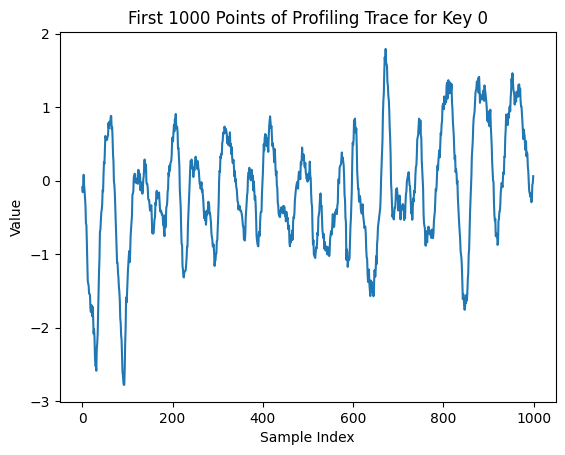

In [11]:
# draw a line plot of the first 1000 points in X_profiling[0]
plot_trace(X_profiling[0][:1000], title='First 1000 Points of Profiling Trace for Key 0')

## Comparison between train and test dataset

In [12]:
# calculate the key-wise average of the profiling traces
key_count = np.zeros(256, dtype=int)
X_profiling_keywise = np.zeros((256, X_profiling.shape[1]), dtype=np.float64)

for i in range(X_profiling.shape[0]):
    key = K_profiling[i]
    X_profiling_keywise[key] += X_profiling[i]
    key_count[key] += 1

# average the traces for each key
for key in range(256):
    if key_count[key] > 0:
        X_profiling_keywise[key] /= key_count[key]

# calculate the key-wise average of the attack traces
counter = 0
X_attack_avg = np.zeros_like(X_profiling[0], dtype=np.float64)

for i in range(len(X_attack)):

    X_attack_avg += X_attack[i]
    counter += 1

X_attack_avg /= counter

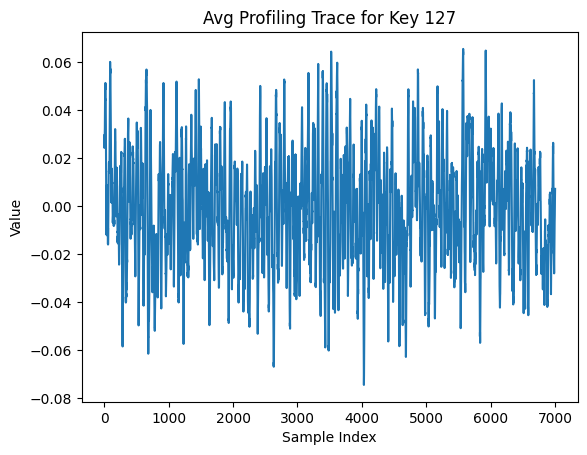

In [21]:
plot_trace(X_profiling_keywise[126], title='Avg Profiling Trace for Key 127')

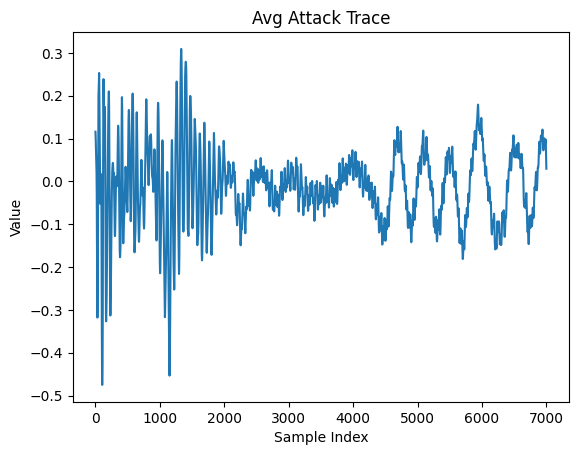

In [15]:
plot_trace(X_attack_avg, title='Avg Attack Trace')

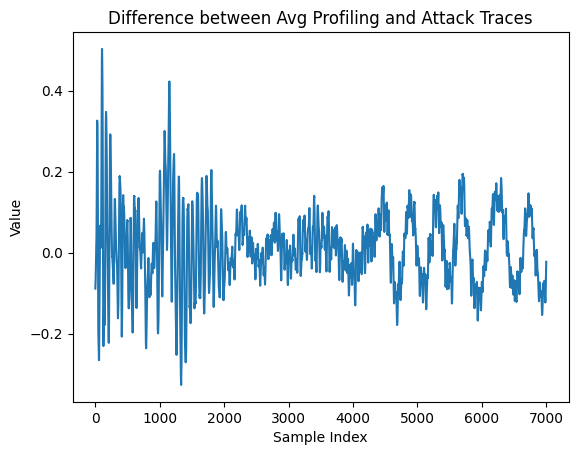

In [ ]:
# Compare the difference between the avg of profiling traces (key = 127) and the avg of attack traces
plot_trace(X_profiling_keywise[126] - X_attack_avg, title='Difference between Avg Profiling and Attack Traces')

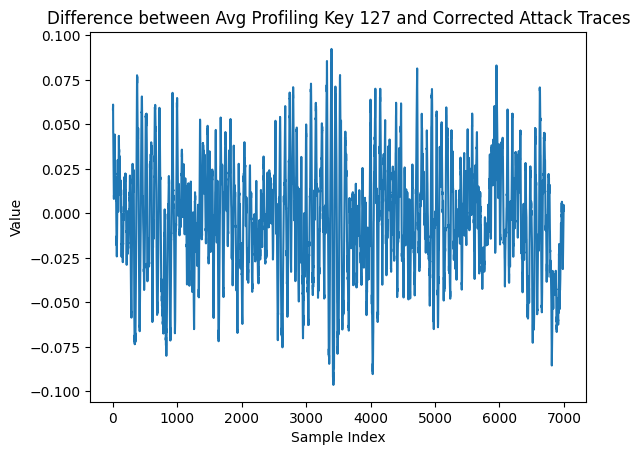

In [ ]:
# The comparison with correction
X_attack_corrected_avg = X_attack_corrected_standard.mean(axis=0, keepdims=False)
plot_trace(X_profiling_keywise[126] - X_attack_corrected_avg, title='Difference between Avg Profiling Key 127 and Corrected Attack Traces')

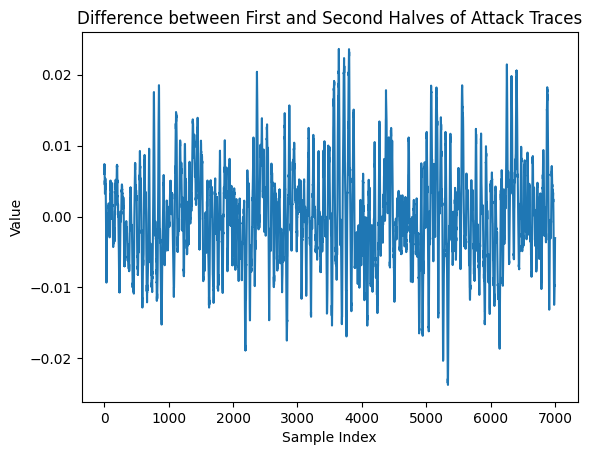

In [83]:
# Compare the first half and second half of the attack traces for key = 127
def half_avg(traces):

    # calculate the key-wise average of the attack traces
    counter = 0
    X_avg1 = np.zeros_like(traces[0], dtype=np.float64)

    for i in range(len(traces) // 2):

        X_avg1 += traces[i]
        counter += 1

    X_avg1 /= counter

    # calculate the key-wise average of the second half
    counter = 0
    X_avg2 = np.zeros_like(traces[0], dtype=np.float64)

    for i in range(len(traces) // 2, len(traces)):

        X_avg2 += traces[i]
        counter += 1

    X_avg2 /= counter

    return X_avg1, X_avg2

X_attack_key127_half1, X_attack_key127_half2 = half_avg(X_attack)

plot_trace(X_attack_key127_half1 - X_attack_key127_half2, title='Difference between First and Second Halves of Attack Traces')

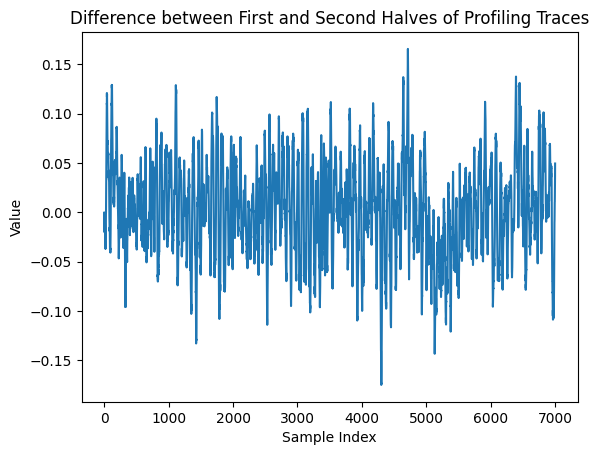

In [85]:
# Compare the first half and second half of the train traces for key = 127
X_profiling_key127 = []
for i in range(len(X_profiling)):
    if K_profiling[i] == 127:
        X_profiling_key127.append(X_profiling[i])
X_profiling_key127 = np.array(X_profiling_key127)

X_profiling_key127_half1, X_profiling_key127_half2 = half_avg(X_profiling_key127)
plot_trace(X_profiling_key127_half1 - X_profiling_key127_half2, title='Difference between First and Second Halves of Profiling Traces')

### Statistical Difference

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict

# ---------- helpers ----------

def _ensure_scores(x):
    """
    If x is 2D (N, T): compute per-trace global mean along axis=1.
    If x is 1D (N,): assume it's already per-trace means.
    """
    x = np.asarray(x)
    if x.ndim == 2:
        return x.mean(axis=1)
    elif x.ndim == 1:
        return x
    else:
        raise ValueError("Input must be 1D (means) or 2D (traces).")

def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """
    Cohen's d for two independent samples.
    d = (mean_a - mean_b) / s_pooled
    """
    a = np.asarray(a); b = np.asarray(b)
    m1, m2 = a.mean(), b.mean()
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    n1, n2 = len(a), len(b)
    # pooled SD (unbiased)
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    if s_pooled == 0:
        return np.inf if m1 != m2 else 0.0
    return (m1 - m2) / s_pooled

def auc_via_ranks(pos: np.ndarray, neg: np.ndarray) -> float:
    """
    AUC computed via rank statistic (no sklearn dependency).
    AUC = P(score_pos > score_neg) + 0.5 * P(tie)
    """
    x = np.concatenate([pos, neg])
    y = np.concatenate([np.ones(len(pos), dtype=int), np.zeros(len(neg), dtype=int)])
    # rank the scores (average ranks for ties)
    order = np.argsort(x, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(x)+1, dtype=float)

    # handle ties: replace tied groups with their mean rank
    # (simple pass since mergesort keeps stability)
    i = 0
    while i < len(x):
        j = i
        while j+1 < len(x) and x[order[j+1]] == x[order[i]]:
            j += 1
        if j > i:
            mean_rank = ranks[order[i:j+1]].mean()
            ranks[order[i:j+1]] = mean_rank
        i = j + 1

    sum_ranks_pos = ranks[y == 1].sum()
    n_pos = (y == 1).sum()
    n_neg = (y == 0).sum()
    # Mann–Whitney U for positives
    U = sum_ranks_pos - n_pos*(n_pos+1)/2.0
    auc = U / (n_pos * n_neg)
    return float(auc)

def youden_threshold(scores: np.ndarray, labels: np.ndarray) -> Tuple[float, Dict[str, float]]:
    """
    Find threshold that maximizes Youden's J = TPR - FPR.
    labels: 1 for 'test', 0 for 'train' (or any two classes)
    """
    # sort unique thresholds from scores
    # we will evaluate thresholds at midpoints between sorted unique scores
    uniq = np.unique(scores)
    if len(uniq) == 1:
        thr = uniq[0]
        # all same scores -> best you can do is majority
        pred = scores >= thr
        acc = (pred == labels).mean()
        return thr, {"tpr": 0.0, "fpr": 0.0, "acc": float(acc)}
    # candidates: midpoints between consecutive unique scores
    mids = (uniq[:-1] + uniq[1:]) / 2.0

    best_J = -np.inf
    best = {"thr": None, "tpr": 0.0, "fpr": 0.0, "acc": 0.0}
    P = labels.sum()
    N = len(labels) - P
    for thr in mids:
        pred = (scores >= thr).astype(int)
        TP = np.sum((pred == 1) & (labels == 1))
        FP = np.sum((pred == 1) & (labels == 0))
        TN = np.sum((pred == 0) & (labels == 0))
        FN = np.sum((pred == 0) & (labels == 1))
        tpr = TP / P if P > 0 else 0.0
        fpr = FP / N if N > 0 else 0.0
        J = tpr - fpr
        acc = (TP + TN) / (P + N)
        if J > best_J:
            best_J = J
            best.update({"thr": float(thr), "tpr": float(tpr), "fpr": float(fpr), "acc": float(acc)})

    return best["thr"], {k: best[k] for k in ("tpr", "fpr", "acc")}

def freedman_diaconis_bins(x: np.ndarray) -> int:
    """
    Robust bin count selection for histogram.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 10
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return int(np.sqrt(x.size))
    bin_width = 2 * iqr * (x.size ** (-1/3))
    if bin_width <= 0:
        return int(np.sqrt(x.size))
    bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return max(bins, 10)

# ---------- main API ----------

def mean_shift_report(
    X_train,
    X_test,
    label_train="train",
    label_test="test",
    plot=True,
) -> Dict[str, float]:
    """
    Compute per-trace global means for two groups and report:
      - Cohen's d
      - AUC (train vs test, using per-trace mean as score)
      - Linear separability by a single threshold
      - Best threshold by Youden's J and its accuracy
    Optionally draw histogram overlay with the best threshold.
    """
    m_train = _ensure_scores(X_train)
    m_test = _ensure_scores(X_test)

    # basic stats
    sep_linear = (m_train.max() < m_test.min()) or (m_test.max() < m_train.min())
    d = cohens_d(m_test, m_train)  # sign: positive if test mean > train mean
    # AUC: define labels 1=test, 0=train; scores = per-trace mean
    scores = np.concatenate([m_train, m_test])
    labels = np.concatenate([np.zeros_like(m_train, dtype=int), np.ones_like(m_test, dtype=int)])
    auc = auc_via_ranks(pos=m_test, neg=m_train)

    thr, jf = youden_threshold(scores, labels)
    # choose which side is "test": we used >= thr => predict test
    pred = (scores >= thr).astype(int)
    acc = (pred == labels).mean()

    if plot:
        bins = max(freedman_diaconis_bins(m_train), freedman_diaconis_bins(m_test))
        plt.figure(figsize=(9, 4.5), dpi=140)
        # NOTE: do not set explicit colors (per your constraint)
        plt.hist(m_train, bins=bins, alpha=0.5, density=True, label=f"{label_train} (N={len(m_train)})")
        plt.hist(m_test,  bins=bins, alpha=0.5, density=True, label=f"{label_test} (N={len(m_test)})")
        # draw threshold
        plt.axvline(thr, linestyle="--", linewidth=2, label=f"Best thr (Youden) = {thr:.6g}")
        plt.xlabel("Per-trace global mean")
        plt.ylabel("Density")
        plt.title("Global-mean histogram: train vs. test")
        plt.legend()
        plt.tight_layout()
        plt.show()

    report = {
        "mean_train": float(m_train.mean()),
        "std_train": float(m_train.std(ddof=1)),
        "mean_test": float(m_test.mean()),
        "std_test": float(m_test.std(ddof=1)),
        "cohens_d": float(d),
        "auc": float(auc),
        "linear_separable_by_threshold": bool(sep_linear),
        "best_threshold": float(thr),
        "best_threshold_acc": float(acc),
        "best_threshold_tpr": float(jf["tpr"]),
        "best_threshold_fpr": float(jf["fpr"]),
    }
    # Pretty print
    print(
        "\n=== Mean-shift check (train vs test) ===\n"
        f"train: mean={report['mean_train']:.6g}, sd={report['std_train']:.6g}, N={len(m_train)}\n"
        f"test : mean={report['mean_test']:.6g}, sd={report['std_test']:.6g}, N={len(m_test)}\n"
        f"Cohen's d      : {report['cohens_d']:.4f}\n"
        f"AUC (mean score): {report['auc']:.4f}\n"
        f"Linear separable: {report['linear_separable_by_threshold']}\n"
        f"Best thr (J)    : {report['best_threshold']:.6g}  "
        f"acc={report['best_threshold_acc']:.4f}, "
        f"TPR={report['best_threshold_tpr']:.4f}, FPR={report['best_threshold_fpr']:.4f}\n"
    )
    return report

# ---------- example usage ----------
# Suppose you already have X_train, X_test with shape (N, T).
# If you only have per-trace means, pass 1D arrays instead.

# report = mean_shift_report(X_train, X_test, label_train="train", label_test="test", plot=True)
# report

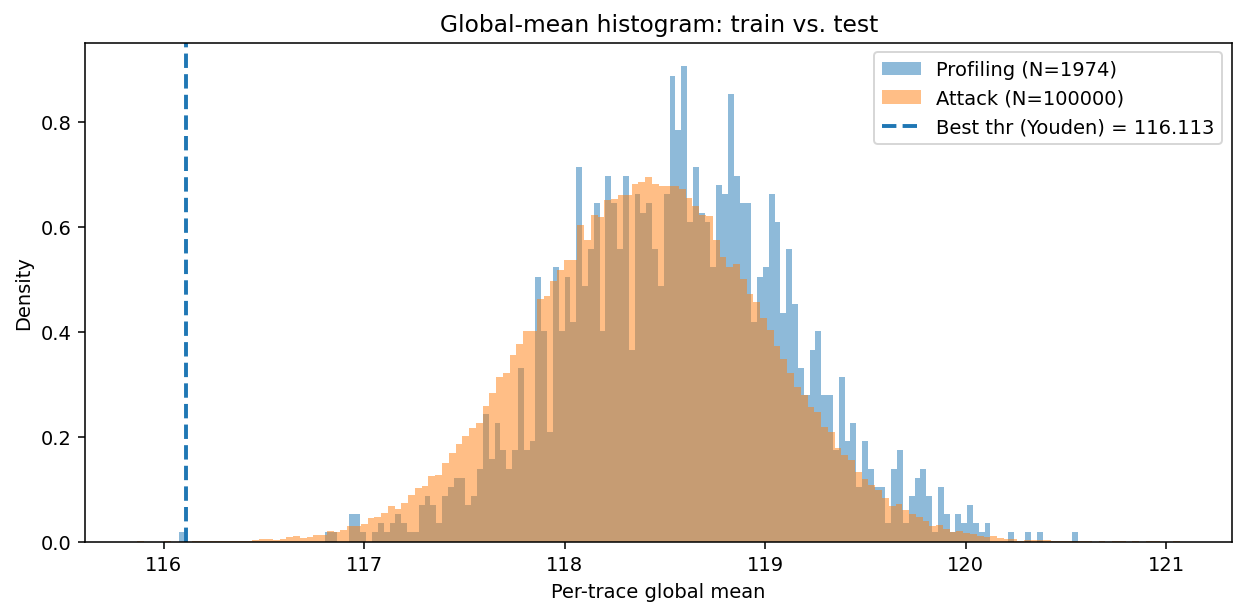


=== Mean-shift check (train vs test) ===
train: mean=118.573, sd=0.570192, N=1974
test : mean=118.418, sd=0.581213, N=100000
Cohen's d      : -0.2672
AUC (mean score): 0.4241
Linear separable: False
Best thr (J)    : 116.113  acc=0.9806, TPR=1.0000, FPR=0.9995



{'mean_train': 118.57349051961211,
 'std_train': 0.5701918056864304,
 'mean_test': 118.41826075857144,
 'std_test': 0.5812125037480524,
 'cohens_d': -0.2671762928010129,
 'auc': 0.4240669098277609,
 'linear_separable_by_threshold': False,
 'best_threshold': 116.113,
 'best_threshold_acc': 0.9806323180418538,
 'best_threshold_tpr': 0.99998,
 'best_threshold_fpr': 0.9994934143870314}

In [55]:
mean_shift_report(X_profiling_key127, X_attack, label_train="Profiling", label_test="Attack", plot=True)

## Data distribution

In [24]:
Y_profiling

array([108, 174, 226, ..., 253,  39,  17], shape=(500000,), dtype=uint8)

In [45]:
def plot_histogram(data, title):
    unique, counts = np.unique(data, return_counts=True)
    plt.bar(unique, counts)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

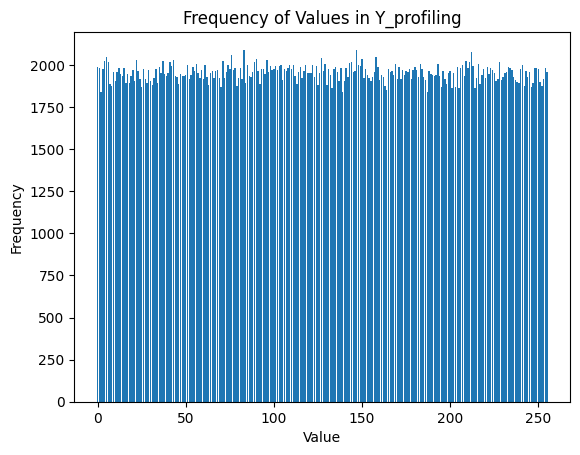

In [46]:
#  Y_profiling
plot_histogram(Y_profiling, 'Frequency of Values in Y_profiling')

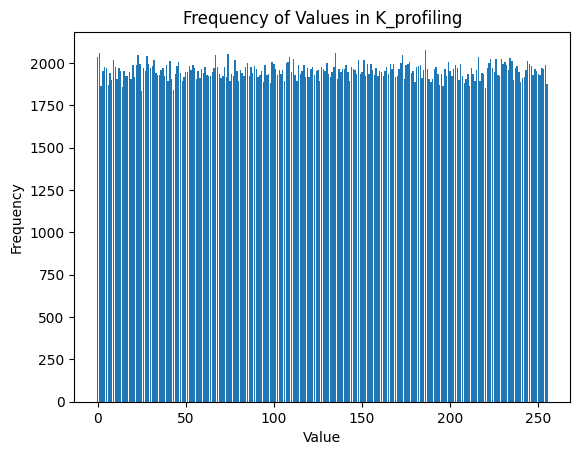

In [43]:
# K_profiling
plot_histogram(K_profiling, 'Frequency of Values in K_profiling')

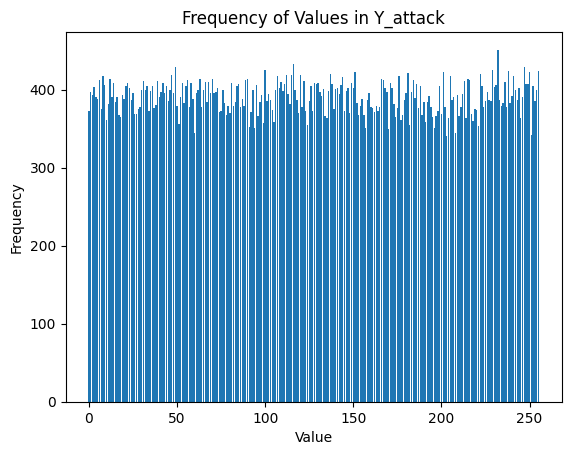

In [44]:
# Y_attack
plot_histogram(Y_attack, 'Frequency of Values in Y_attack')

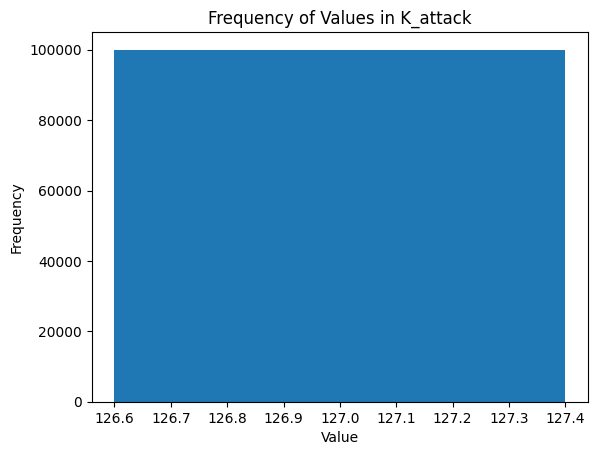

In [45]:
# K_attack
plot_histogram(K_attack, 'Frequency of Values in K_attack')